In [1]:
# Libraries

import os
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torchvision.models import resnet50
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.optim as optim
from tqdm import tqdm

Here the metric is normal dice but wherever the true and predicted masks are blank it is omited as to not negatively impact the code

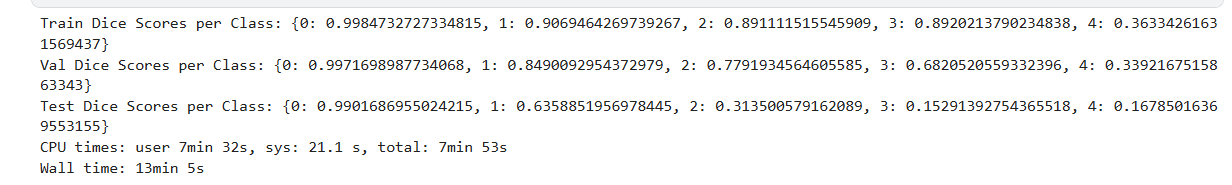

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader

class SegmentationEvaluator:
    """
    A class for evaluating segmentation performance using the Dice coefficient.
    Uses vectorized computation (with one-hot encoding) and GPU acceleration.
    For each class in a sample, if both the true mask and the predicted mask are blank,
    that sample is omitted from the Dice score calculation.
    """
    def __init__(self, model, num_classes=5, eval_batch_size=4, device=None):
        """
        Args:
            model (torch.nn.Module): Trained segmentation model.
            num_classes (int): Number of segmentation classes.
            eval_batch_size (int): Batch size for evaluation.
            device (torch.device): Device to perform computations (GPU/CPU). 
                                   If None, GPU is chosen if available.
        """
        self.model = model
        self.num_classes = num_classes
        self.eval_batch_size = eval_batch_size
        self.device = device if device is not None else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        
        # Define class labels (keys correspond to values in the segmentation mask)
        self.class_labels = {
            0: 'Background', 
            1: 'Liver', 
            2: 'Tumor', 
            3: 'Aorta', 
            4: 'Vessel'
        }
    
    def evaluate_dice(self, dataset):
        """
        Evaluate the average Dice coefficient for each class over the dataset.
        Uses vectorized computation to compute Dice scores over the batch.
        For each class, if both the true mask and predicted mask are blank for a sample,
        that sample is omitted from the Dice calculation.
        
        Args:
            dataset (torch.utils.data.Dataset): Dataset that returns (ct_image, mask) pairs.
        
        Returns:
            dict: Average Dice score per class.
        """
        dataloader = DataLoader(dataset, batch_size=self.eval_batch_size, shuffle=False)
        dice_scores_per_class = {c: [] for c in range(self.num_classes)}
        
        self.model.eval()
        with torch.no_grad():
            for ct_images, true_masks in dataloader:
                # Move data to device.
                ct_images = ct_images.to(self.device)   # Shape: (B, 1, H, W)
                true_masks = true_masks.to(self.device)   # Shape: (B, H, W)
                
                # Forward pass.
                preds = self.model(ct_images)
                # If the model returns a tuple (main_out, aux_out), take only the main output.
                if isinstance(preds, (tuple, list)):
                    preds = preds[0]
                    
                # Expected shape: (B, num_classes, H, W)
                pred_masks = torch.argmax(preds, dim=1)   # Shape: (B, H, W)
                
                # Compute one-hot encodings for predicted and true masks.
                pred_onehot = F.one_hot(pred_masks, num_classes=self.num_classes)  # (B, H, W, num_classes)
                pred_onehot = pred_onehot.permute(0, 3, 1, 2).float()                # (B, num_classes, H, W)
                true_onehot = F.one_hot(true_masks, num_classes=self.num_classes)    # (B, H, W, num_classes)
                true_onehot = true_onehot.permute(0, 3, 1, 2).float()                # (B, num_classes, H, W)
                
                # Compute intersection and union over spatial dimensions.
                intersection = (pred_onehot * true_onehot).sum(dim=(2, 3))           # (B, num_classes)
                union = pred_onehot.sum(dim=(2, 3)) + true_onehot.sum(dim=(2, 3))       # (B, num_classes)
                
                # Compute Dice score (B, num_classes).
                dice = (2.0 * intersection) / (union + 1e-6)
                
                # For each class, only include samples where not both masks are blank.
                for c in range(self.num_classes):
                    # Compute the sum over spatial dimensions for both masks.
                    true_sum = true_onehot[:, c, :, :].sum(dim=(1,2))
                    pred_sum = pred_onehot[:, c, :, :].sum(dim=(1,2))
                    # Valid samples: at least one mask is non-blank.
                    valid = ~((true_sum == 0) & (pred_sum == 0))
                    if valid.sum() > 0:
                        valid_dice = dice[:, c][valid]
                        dice_scores_per_class[c].extend(valid_dice.cpu().numpy().tolist())
                    
        # Average dice score per class over the entire dataset.
        avg_dice_scores = {c: np.mean(dice_scores_per_class[c]) if dice_scores_per_class[c] else None
                           for c in range(self.num_classes)}
        return avg_dice_scores

    def predict_mask(self, ct_image):
        """
        Predict the segmentation mask for a single CT image.
        
        Args:
            ct_image (torch.Tensor): CT image tensor of shape (1, H, W).
        
        Returns:
            torch.Tensor: Predicted mask of shape (H, W).
        """
        self.model.eval()
        with torch.no_grad():
            ct_image = ct_image.to(self.device)
            pred = self.model(ct_image.unsqueeze(0))
            pred_mask = torch.argmax(pred, dim=1).squeeze(0)
        return pred_mask.cpu()


In [3]:
import torch
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader

class Evaluator:
    """
    A class for evaluating segmentation performance using the Dice coefficient.
    Uses vectorized computation (with one-hot encoding) and GPU acceleration.
    """
    def __init__(self, model, num_classes=5, eval_batch_size=4, device=None):
        """
        Args:
            model (torch.nn.Module): Trained segmentation model.
            num_classes (int): Number of segmentation classes.
            eval_batch_size (int): Batch size for evaluation.
            device (torch.device): Device to perform computations (GPU/CPU). 
                                   If None, GPU is chosen if available.
        """
        self.model = model
        self.num_classes = num_classes
        self.eval_batch_size = eval_batch_size
        self.device = device if device is not None else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        
        # Define class labels (keys correspond to values in the segmentation mask)
        self.class_labels = {
            0: 'Background', 
            1: 'Liver', 
            2: 'Tumor', 
            3: 'Aorta', 
            4: 'Vessel'
        }
    
    def evaluate_dice(self, dataset):
        """
        Evaluate the average Dice coefficient for each class over the dataset.
        Uses vectorized computation to compute dice scores over the batch.
        
        Args:
            dataset (torch.utils.data.Dataset): Dataset that returns (ct_image, mask) pairs.
        
        Returns:
            dict: Average Dice score per class.
        """
        dataloader = DataLoader(dataset, batch_size=self.eval_batch_size, shuffle=False)
        dice_scores_per_class = {c: [] for c in range(self.num_classes)}
        
        self.model.eval()
        with torch.no_grad():
            for ct_images, true_masks in dataloader:
                # Move data to device.
                ct_images = ct_images.to(self.device)   # Shape: (B, 1, H, W)
                true_masks = true_masks.to(self.device) # Shape: (B, H, W)
                
                # Forward pass.
                preds = self.model(ct_images)
                # If the model returns a tuple (main_out, aux_out), take only the main output.
                if isinstance(preds, (tuple, list)):
                    preds = preds[0]
                    
                # Expected shape: (B, num_classes, H, W)
                pred_masks = torch.argmax(preds, dim=1)   # Shape: (B, H, W)
                
                # Compute one-hot encodings for predicted and true masks.
                pred_onehot = F.one_hot(pred_masks, num_classes=self.num_classes)  # (B, H, W, num_classes)
                pred_onehot = pred_onehot.permute(0, 3, 1, 2).float()                # (B, num_classes, H, W)
                true_onehot = F.one_hot(true_masks, num_classes=self.num_classes)    # (B, H, W, num_classes)
                true_onehot = true_onehot.permute(0, 3, 1, 2).float()                # (B, num_classes, H, W)
                
                # Compute intersection and union over spatial dimensions.
                intersection = (pred_onehot * true_onehot).sum(dim=(2, 3))           # (B, num_classes)
                union = pred_onehot.sum(dim=(2, 3)) + true_onehot.sum(dim=(2, 3))       # (B, num_classes)
                
                # Compute Dice score (B, num_classes).
                dice = (2.0 * intersection) / (union + 1e-6)
                
                # Append scores per class.
                for c in range(self.num_classes):
                    
                    dice_scores_per_class[c].extend(dice[:, c].cpu().numpy().tolist())
                    
        # Average dice score per class over the entire dataset.
        avg_dice_scores = {c: np.mean(dice_scores_per_class[c]) if dice_scores_per_class[c] else None
                           for c in range(self.num_classes)}
        return avg_dice_scores

    def predict_mask(self, ct_image):
        """
        Predict the segmentation mask for a single CT image.
        
        Args:
            ct_image (torch.Tensor): CT image tensor of shape (1, H, W).
        
        Returns:
            torch.Tensor: Predicted mask of shape (H, W).
        """
        self.model.eval()
        with torch.no_grad():
            ct_image = ct_image.to(self.device)
            pred = self.model(ct_image.unsqueeze(0))
            pred_mask = torch.argmax(pred, dim=1).squeeze(0)
        return pred_mask.cpu()


In [4]:
# Archeitecture
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

# Squeeze and Excitation Block
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction = 4):
        super(SEBlock, self).__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction),
            nn.LeakyReLU(inplace = True),
            nn.Linear(in_channels//reduction, in_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        se_weight = self.global_avg_pool(x).view(b, c)
        se_weight = self.fc(se_weight).view(b, c, 1, 1)
        # print(se_weight)
        return x * se_weight

class UNet(nn.Module):
    def __init__(self, in_channels = 1, num_classes = 5):
        super(UNet, self).__init__()
        
        self.resnet = resnet50(weights = ResNet50_Weights.DEFAULT)
        self.resnet.conv1 = nn.Conv2d(in_channels, 64, kernel_size = 7, stride = 2, padding = 3, bias = False)
        self.resnet = nn.Sequential(*list(self.resnet.children())[:-2])
        
        self.up_transpose_1 = nn.ConvTranspose2d(2048, 1024, kernel_size = 2, stride = 2)
        self.up_convolution_1 = self.double_convolution(2048, 1024)
        self.se1 = SEBlock(1024) # Just for reweighting

        self.up_transpose_2 = nn.ConvTranspose2d(1024, 512, kernel_size = 2, stride = 2)
        self.up_convolution_2 = self.double_convolution(1024, 512)
        self.se2 = SEBlock(512) # Just for reweighting

        self.up_transpose_3 = nn.ConvTranspose2d(512, 256, kernel_size = 2, stride = 2)
        self.up_convolution_3 = self.double_convolution(512, 256)
        self.se3 = SEBlock(256) # Just for reweighting

        # Auxiliary branch for deep supervision (added at the third upsampling block)
        self.aux = nn.Conv2d(256, num_classes, kernel_size=1)

        self.up_transpose_4 = nn.ConvTranspose2d(256, 64, kernel_size = 2, stride = 2)
        self.up_convolution_4 = self.double_convolution(128, 64)
        self.se4 = SEBlock(64) # Just for reweighting

        self.refine = self.double_convolution(64, 64)

        self.out = nn.Conv2d(64, num_classes, kernel_size = 1)

        

    def double_convolution(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(inplace = True),
            nn.Conv2d(out_channels, out_channels, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(inplace = True),
            nn.Dropout(0.3)
        )


    def forward(self, x):
        features = []
        for module in self.resnet:
            x = module(x)
            features.append(x)

        x = self.up_transpose_1(features[-1])
        x = self.up_convolution_1(torch.cat([x, features[-2]], 1))
        x = self.se1(x)

        x = self.up_transpose_2(x)
        x = self.up_convolution_2(torch.cat([x, features[-3]], 1))
        x = self.se2(x)

        x = self.up_transpose_3(x)
        x = self.up_convolution_3(torch.cat([x, features[-4]], 1))
        x = self.se3(x)

        aux_out = self.aux(x)  # Auxiliary segmentation head
        aux_out = nn.functional.interpolate(aux_out, size=(512, 512), mode='bilinear', align_corners=False)


        x = self.up_transpose_4(x)
        features_3_upsampled = nn.functional.interpolate(features[3], scale_factor=2, mode='bilinear', align_corners=False)
        x = self.up_convolution_4(torch.cat([x, features_3_upsampled], 1))
        x = self.se4(x)

        x = self.refine(x)
        main_out = self.out(x)
        main_out = nn.functional.interpolate(main_out, size=(512, 512), mode='bilinear', align_corners=False)

        return main_out, aux_out

In [5]:
import numpy as np
import torch
from torch.utils.data import Dataset

class MulticlassSegmentationDataset(Dataset):
    def __init__(self, ct_paths, liver_paths, aorta_paths, vessel_paths, tumor_paths, transform=None, skip_empty=True, threshold=0.25):
        """
        Args:
            ct_paths (list): List of file paths to CT images.
            liver_paths (list): List of file paths to liver masks.
            aorta_paths (list): List of file paths to aorta masks.
            vessel_paths (list): List of file paths to vessel masks.
            tumor_paths (list): List of file paths to tumor masks.
            transform (callable, optional): Optional transform to be applied on a sample.
            skip_empty (bool): If True, skip samples where the aorta or vessel mask is empty.
            threshold (float): Threshold to determine if a mask is empty.
        """
        self.transform = transform
        self.skip_empty = skip_empty
        self.threshold = threshold

        # If skipping empty masks, filter out those samples.
        if self.skip_empty:
            valid_indices = []
            for i in range(len(ct_paths)):
                # Load the aorta and vessel masks.
                aorta_mask = np.load(aorta_paths[i])
                vessel_mask = np.load(vessel_paths[i])
                # Check if there is at least one pixel with value >= threshold.
                if np.any(aorta_mask >= threshold) or np.any(vessel_mask >= threshold):
                    valid_indices.append(i)
            # Filter the lists according to valid indices.
            self.ct_paths = [ct_paths[i] for i in valid_indices]
            self.liver_paths = [liver_paths[i] for i in valid_indices]
            self.aorta_paths = [aorta_paths[i] for i in valid_indices]
            self.vessel_paths = [vessel_paths[i] for i in valid_indices]
            self.tumor_paths = [tumor_paths[i] for i in valid_indices]
        else:
            self.ct_paths = ct_paths
            self.liver_paths = liver_paths
            self.aorta_paths = aorta_paths
            self.vessel_paths = vessel_paths
            self.tumor_paths = tumor_paths

    def __len__(self):
        return len(self.ct_paths)

    def __getitem__(self, idx):
        # Load CT and Mask
        ct_image = np.load(self.ct_paths[idx])  
        liver_mask = np.load(self.liver_paths[idx])
        aorta_mask = np.load(self.aorta_paths[idx])
        tumor_mask = np.load(self.tumor_paths[idx])
        vessel_mask = np.load(self.vessel_paths[idx])

        # Normalize CT image from [-1024, 1024] to [0, 1]
        ct_image = (ct_image + 1024) / 2048.0
        ct_image = np.clip(ct_image, a_min=0.85, a_max=1.3)

        # Create a multiclass mask (5 classes: Background, Liver, Tumor, Aorta, Vessel)
        multiclass_mask = np.zeros((ct_image.shape[0], ct_image.shape[1]), dtype=np.uint8)
        multiclass_mask[liver_mask >= self.threshold] = 1  # Liver
        multiclass_mask[tumor_mask >= self.threshold] = 2  # Tumor
        multiclass_mask[aorta_mask >= self.threshold] = 3  # Aorta
        multiclass_mask[vessel_mask >= self.threshold] = 4  # Vessel

        # Expand dimensions for CT image (add channel dimension)
        ct_image = np.expand_dims(ct_image, axis=0)  # (1, H, W)

        # Convert to Tensors
        ct_image = torch.tensor(ct_image, dtype=torch.float32)
        multiclass_mask = torch.tensor(multiclass_mask, dtype=torch.long)

        if self.transform is not None:
            ct_image = self.transform(ct_image)

        return ct_image, multiclass_mask


In [6]:
# Retrieving Data and Splitting Test and Train

ROOT = r'/kaggle/input/nowindow-raw/OUTPUT/ct_images'
DIR = os.listdir(ROOT)
paths = [entry for entry in DIR if os.path.isdir(os.path.join(ROOT, entry))]
# print(paths)

# random.shuffle(paths)
paths_train = paths[:len(paths)*4//5]
paths_test = paths[len(paths)*4//5:]


# paths_train, paths_test = train_test_split(paths, test_size = 0.2, random_state = 42)

In [7]:
paths_test

['HCC_071',
 'HCC_087',
 'HCC_074',
 'HCC_047',
 'HCC_005',
 'HCC_024',
 'HCC_063',
 'HCC_097',
 'HCC_020',
 'HCC_018',
 'HCC_044',
 'HCC_006',
 'HCC_093',
 'HCC_086',
 'HCC_058',
 'HCC_099',
 'HCC_061',
 'HCC_004',
 'HCC_040',
 'HCC_019',
 'HCC_010']

In [8]:
# Getting the train, val dataset

Images = []
LiverMask = []
AortaMask = []
VesselMask = []
TumorMask = []

ROOT = r'/kaggle/input/nowindow-raw/OUTPUT/ct_images'
ROOT_BASE = r'/kaggle/input/nowindow-raw/OUTPUT'
MasksType = ['LIVER', 'AORTA', 'VESSELS', 'TUMOR']
MasksType = [x.lower() for x in MasksType]

for direct in paths_train:
    Images.extend([os.path.join(ROOT, direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    LiverMask.extend([os.path.join(ROOT_BASE, MasksType[0], direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    AortaMask.extend([os.path.join(ROOT_BASE, MasksType[1], direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    VesselMask.extend([os.path.join(ROOT_BASE, MasksType[2], direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    TumorMask.extend([os.path.join(ROOT_BASE, MasksType[3], direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    
# Images, Mask
# trainImages, testImages, trainMasks, testMasks = train_test_split(Images, Mask, test_size = 0.2, random_state = 42)
trainImages, valImages, trainliverMasks, valliverMasks, trainaortaMasks, valaortaMasks, trainvesselMasks, valvesselMasks, traintumorMasks, valtumorMasks = train_test_split(Images, LiverMask, AortaMask, VesselMask, TumorMask, test_size=0.2, random_state=42)

In [9]:
TestImages = []
TestLiverMask = []
TestAortaMask = []
TestVesselMask = []
TestTumorMask = []

ROOT = r'/kaggle/input/nowindow-raw/OUTPUT/ct_images'
ROOT_BASE = r'/kaggle/input/nowindow-raw/OUTPUT'
MasksType = ['LIVER', 'AORTA', 'VESSELS', 'TUMOR']
MasksType = [x.lower() for x in MasksType]

for direct in paths_test:
    TestImages.extend([os.path.join(ROOT, direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    TestLiverMask.extend([os.path.join(ROOT_BASE, MasksType[0], direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    TestAortaMask.extend([os.path.join(ROOT_BASE, MasksType[1], direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    TestVesselMask.extend([os.path.join(ROOT_BASE, MasksType[2], direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    TestTumorMask.extend([os.path.join(ROOT_BASE, MasksType[3], direct, entry) for entry in os.listdir(os.path.join(ROOT, direct))])
    

In [10]:
valImages[:5], trainaortaMasks[:5]

(['/kaggle/input/nowindow-raw/OUTPUT/ct_images/HCC_053/HCC_053_37.npy',
  '/kaggle/input/nowindow-raw/OUTPUT/ct_images/HCC_008/HCC_008_137.npy',
  '/kaggle/input/nowindow-raw/OUTPUT/ct_images/HCC_034/HCC_034_9.npy',
  '/kaggle/input/nowindow-raw/OUTPUT/ct_images/HCC_013/HCC_013_76.npy',
  '/kaggle/input/nowindow-raw/OUTPUT/ct_images/HCC_082/HCC_082_69.npy'],
 ['/kaggle/input/nowindow-raw/OUTPUT/aorta/HCC_098/HCC_098_66.npy',
  '/kaggle/input/nowindow-raw/OUTPUT/aorta/HCC_076/HCC_076_5.npy',
  '/kaggle/input/nowindow-raw/OUTPUT/aorta/HCC_103/HCC_103_144.npy',
  '/kaggle/input/nowindow-raw/OUTPUT/aorta/HCC_090/HCC_090_16.npy',
  '/kaggle/input/nowindow-raw/OUTPUT/aorta/HCC_092/HCC_092_202.npy'])

In [11]:
'''import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

class SegmentationStats:
    """
    Compute intensity statistics and histograms for each region (Background, Liver, Tumor, Aorta, Vessel)
    in a multiclass segmentation dataset. This version dynamically computes the global min and max for each region,
    so that the histogram covers the entire intensity range, regardless of what it is.
    """
    def __init__(self, dataset, batch_size=1, bins=50):
        """
        Args:
            dataset: A PyTorch Dataset returning (ct_image, multiclass_mask) pairs.
            batch_size: Batch size for the DataLoader.
            bins: Number of bins for the histogram.
        """
        self.dataset = dataset
        self.batch_size = batch_size
        self.bins = bins
        
        # Define class labels (keys correspond to values in the segmentation mask)
        self.class_labels = {
            0: 'Background', 
            1: 'Liver', 
            2: 'Tumor', 
            3: 'Aorta', 
            4: 'Vessel'
        }
        # Containers for statistics
        self.stats = {}   # To store final stats: min, max, avg for each region.
        self.counts = {cls: 0 for cls in self.class_labels.keys()}   # Total pixel count per region.
        self.sums = {cls: 0.0 for cls in self.class_labels.keys()}     # Sum of intensities per region.
        self.mins = {cls: None for cls in self.class_labels.keys()}    # Global min per region.
        self.maxs = {cls: None for cls in self.class_labels.keys()}    # Global max per region.
        # Histogram-related containers (set in the second pass)
        self.hist_counts = {}   # Dictionary: key = class, value = histogram counts array.
        self.bin_edges = {}     # Dictionary: key = class, value = bin edges array.

    def compute_statistics(self):
        """First pass: Compute global min, max, and average intensities for each region."""
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        dataloader = DataLoader(self.dataset, batch_size=self.batch_size, shuffle=False)
        
        for ct_image, mask in dataloader:
            # Move to device (GPU/CPU)
            ct_image = ct_image.to(device)   # shape: (B, 1, H, W)
            mask = mask.to(device)           # shape: (B, H, W)
            
            # Squeeze batch and channel dimensions (assumes batch_size=1 for simplicity)
            ct_tensor = ct_image.squeeze()   # shape: (H, W)
            mask_tensor = mask.squeeze()     # shape: (H, W)
            
            for cls in self.class_labels.keys():
                # Boolean mask for the region
                region_mask = (mask_tensor == cls)
                if region_mask.sum() > 0:
                    # Get intensities (move to CPU for numpy operations)
                    region_intensities = ct_tensor[region_mask].cpu().numpy()
                    # Update count and sum for average computation
                    self.counts[cls] += region_intensities.size
                    self.sums[cls] += region_intensities.sum()
                    
                    # Update global minimum and maximum
                    current_min = np.min(region_intensities)
                    current_max = np.max(region_intensities)
                    if self.mins[cls] is None:
                        self.mins[cls] = current_min
                    else:
                        self.mins[cls] = min(self.mins[cls], current_min)
                    if self.maxs[cls] is None:
                        self.maxs[cls] = current_max
                    else:
                        self.maxs[cls] = max(self.maxs[cls], current_max)
        
        # Compute average for each class and store final statistics.
        for cls in self.class_labels.keys():
            if self.counts[cls] > 0:
                avg = self.sums[cls] / self.counts[cls]
            else:
                avg = None
            self.stats[cls] = {
                'min': self.mins[cls],
                'max': self.maxs[cls],
                'avg': avg
            }
        return self.stats

    def compute_histograms(self):
        """
        Second pass: Compute histograms for each region using bin edges defined from the global min and max,
        ensuring that the entire intensity range is covered.
        """
        # Set bin edges for each region based on global min and max.
        for cls in self.class_labels.keys():
            if self.counts[cls] > 0:
                self.bin_edges[cls] = np.linspace(self.mins[cls], self.maxs[cls], self.bins + 1)
                self.hist_counts[cls] = np.zeros(self.bins)
            else:
                self.bin_edges[cls] = None
                self.hist_counts[cls] = None

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        dataloader = DataLoader(self.dataset, batch_size=self.batch_size, shuffle=False)
        
        # Loop over dataset to accumulate histogram counts.
        for ct_image, mask in dataloader:
            ct_image = ct_image.to(device)
            mask = mask.to(device)
            ct_tensor = ct_image.squeeze()   # shape: (H, W)
            mask_tensor = mask.squeeze()     # shape: (H, W)
            
            for cls in self.class_labels.keys():
                if self.counts[cls] > 0:
                    region_mask = (mask_tensor == cls)
                    if region_mask.sum() > 0:
                        region_intensities = ct_tensor[region_mask].cpu().numpy()
                        # Compute histogram with fixed bin edges for this region.
                        counts, _ = np.histogram(region_intensities, bins=self.bin_edges[cls])
                        self.hist_counts[cls] += counts

    def plot_histograms(self):
        """Plot histograms for each region using the pre-computed histogram counts and bin edges."""
        for cls in self.class_labels.keys():
            if self.counts[cls] > 0 and self.hist_counts[cls] is not None:
                plt.figure()
                bin_edges = self.bin_edges[cls]
                plt.bar(bin_edges[:-1], self.hist_counts[cls], 
                        width=(bin_edges[1] - bin_edges[0]), align='edge',
                        alpha=0.75, color='blue')
                label = self.class_labels.get(cls, f"Class {cls}")
                plt.title(f"Histogram of {label} Region\n(Range: {self.mins[cls]:.2f} to {self.maxs[cls]:.2f})")
                plt.xlabel("CT Intensity")
                plt.ylabel("Frequency")
                plt.grid(True)
                plt.show()
            else:
                print(f"No data for class {cls} ({self.class_labels.get(cls)}) to plot.")

# -----------------------------------------------------------------------------
# Example Usage
# -----------------------------------------------------------------------------

# Assuming trainImages, trainliverMasks, trainaortaMasks, trainvesselMasks, traintumorMasks are defined.
dataset = MulticlassSegmentationDataset(trainImages, trainliverMasks, trainaortaMasks, trainvesselMasks, traintumorMasks)

# Instantiate the statistics class.
stats_calculator = SegmentationStats(dataset, batch_size=1, bins=50)

# First pass: Compute global statistics.
region_stats = stats_calculator.compute_statistics()
print("Region Statistics:")
for cls, stat in region_stats.items():
    label = stats_calculator.class_labels.get(cls, f"Class {cls}")
    print(f"{label}: min = {stat['min']}, max = {stat['max']}, avg = {stat['avg']}")

# Second pass: Compute histograms over the entire range for each region.
stats_calculator.compute_histograms()

# Plot histograms for each region.
stats_calculator.plot_histograms()
'''

'import numpy as np\nimport torch\nfrom torch.utils.data import DataLoader\nimport matplotlib.pyplot as plt\n\nclass SegmentationStats:\n    """\n    Compute intensity statistics and histograms for each region (Background, Liver, Tumor, Aorta, Vessel)\n    in a multiclass segmentation dataset. This version dynamically computes the global min and max for each region,\n    so that the histogram covers the entire intensity range, regardless of what it is.\n    """\n    def __init__(self, dataset, batch_size=1, bins=50):\n        """\n        Args:\n            dataset: A PyTorch Dataset returning (ct_image, multiclass_mask) pairs.\n            batch_size: Batch size for the DataLoader.\n            bins: Number of bins for the histogram.\n        """\n        self.dataset = dataset\n        self.batch_size = batch_size\n        self.bins = bins\n        \n        # Define class labels (keys correspond to values in the segmentation mask)\n        self.class_labels = {\n            0: \'Bac

In [12]:
dataset = MulticlassSegmentationDataset(trainImages, trainliverMasks, trainaortaMasks, trainvesselMasks, traintumorMasks)
batch_size = 15

train_dataset = MulticlassSegmentationDataset(trainImages, trainliverMasks, trainaortaMasks, trainvesselMasks, traintumorMasks)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

val_dataset = MulticlassSegmentationDataset(valImages, valliverMasks, valaortaMasks, valvesselMasks, valtumorMasks)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

test_dataset = MulticlassSegmentationDataset(TestImages, TestLiverMask, TestAortaMask, TestVesselMask, TestTumorMask)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

unet_model = UNet(in_channels = 1, num_classes = 5).to(device)
optimizer = optim.Adam(unet_model.parameters(), lr = 1e-4)

# Define class weights (example: higher weight for classes that are underrepresented)
# class_weights = torch.tensor([1.0, 1.0, 25, 1.0, 1.0], dtype=torch.float).to(device)
# criterion = nn.CrossEntropyLoss(weight=class_weights)
criterion = nn.CrossEntropyLoss()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


In [13]:
# model = UNet(in_channels = 1, num_classes = 5)
# model.load_state_dict(torch.load('/kaggle/input/resunet/unet_multiclass_fin.pth'))
# # model = torch.load('/kaggle/input/hcc-2025/unet_multiclass_fin.pth', weights_only=False)
# # model.eval()
# unet_model = model.to(device)

In [14]:
optimzer = optim.Adam(unet_model.parameters(), lr = 1e-3)
num_epochs = 10
for epoch in range(num_epochs):
    unet_model.train()
    running_loss = 0.0
    for i, (ct_images, masks) in enumerate(tqdm(train_dataloader)):
        ct_images = ct_images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        main_out, aux_out = unet_model(ct_images)

        main_loss = criterion(main_out, masks)
        aux_loss = criterion(aux_out, masks)

        loss = main_loss + 0.4 * aux_loss
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_dataloader)}')
    
    # Validation phase
    unet_model.eval()
    val_loss = 0.0
    # dice_scores = []
    with torch.no_grad():
        for val_images, val_masks in val_dataloader:
            val_images = val_images.to(device)
            val_masks = val_masks.to(device)
            main_out, _ = unet_model(val_images)  # Use the main output for evaluation
            loss = criterion(main_out, val_masks)
            val_loss += loss.item()
            
            # # Assuming dice_function computes Dice for a batch
            # dice = dice_function(main_out, val_masks)
            # dice_scores.append(dice)
    
    avg_val_loss = val_loss / len(val_dataloader)
    # avg_dice = np.mean(dice_scores)
    print(f"Epoch {epoch + 1}: Val Loss = {avg_val_loss:.4f}")
    
    # # Optional: Save model checkpoint if validation performance improved
    # if avg_dice > best_val_dice:
    #     best_val_dice = avg_dice
    #     torch.save(model.state_dict(), "best_model.pth")

    
torch.save(unet_model.state_dict(), 'unet_multiclass_1.pth')

100%|██████████| 239/239 [06:02<00:00,  1.52s/it]


Epoch 1/10, Loss: 0.9741149045932243
Epoch 1: Val Loss = 0.5102


100%|██████████| 239/239 [04:38<00:00,  1.17s/it]


Epoch 2/10, Loss: 0.41861867605392905
Epoch 2: Val Loss = 0.2436


100%|██████████| 239/239 [04:37<00:00,  1.16s/it]


...

Epoch 8/10, Loss: 0.06315254897003893
Epoch 8: Val Loss = 0.0592


100%|██████████| 239/239 [04:37<00:00,  1.16s/it]


Epoch 9/10, Loss: 0.05480719884569176
Epoch 9: Val Loss = 0.0551


100%|██████████| 239/239 [04:38<00:00,  1.16s/it]


Epoch 10/10, Loss: 0.0486325081671631
Epoch 10: Val Loss = 0.0457


In [15]:
%%time
evaluator = SegmentationEvaluator(unet_model, num_classes=5, eval_batch_size=4)

# Evaluate on the training dataset
train_dice_scores = evaluator.evaluate_dice(train_dataset)
print("Train Dice Scores per Class:", train_dice_scores)

# Evaluate on the validation dataset
val_dice_scores = evaluator.evaluate_dice(val_dataset)
print("Val Dice Scores per Class:", val_dice_scores)

# Evaluate on the test dataset
test_dice_scores = evaluator.evaluate_dice(test_dataset)
print("Test Dice Scores per Class:", test_dice_scores)

Train Dice Scores per Class: {0: 0.9962279001538944, 1: 0.9080173842004771, 2: 0.800756429319017, 3: 0.7689410301539078, 4: 0.22818670697756932}
Val Dice Scores per Class: {0: 0.9948630865684337, 1: 0.8821759142964073, 2: 0.7008412067420208, 3: 0.6081394183079469, 4: 0.21530871678725538}
Test Dice Scores per Class: {0: 0.9822658652146355, 1: 0.7408290224346544, 2: 0.25974321282418067, 3: 0.2681129429222576, 4: 0.11017441381323699}
CPU times: user 3min 58s, sys: 6.46 s, total: 4min 5s
Wall time: 3min 50s


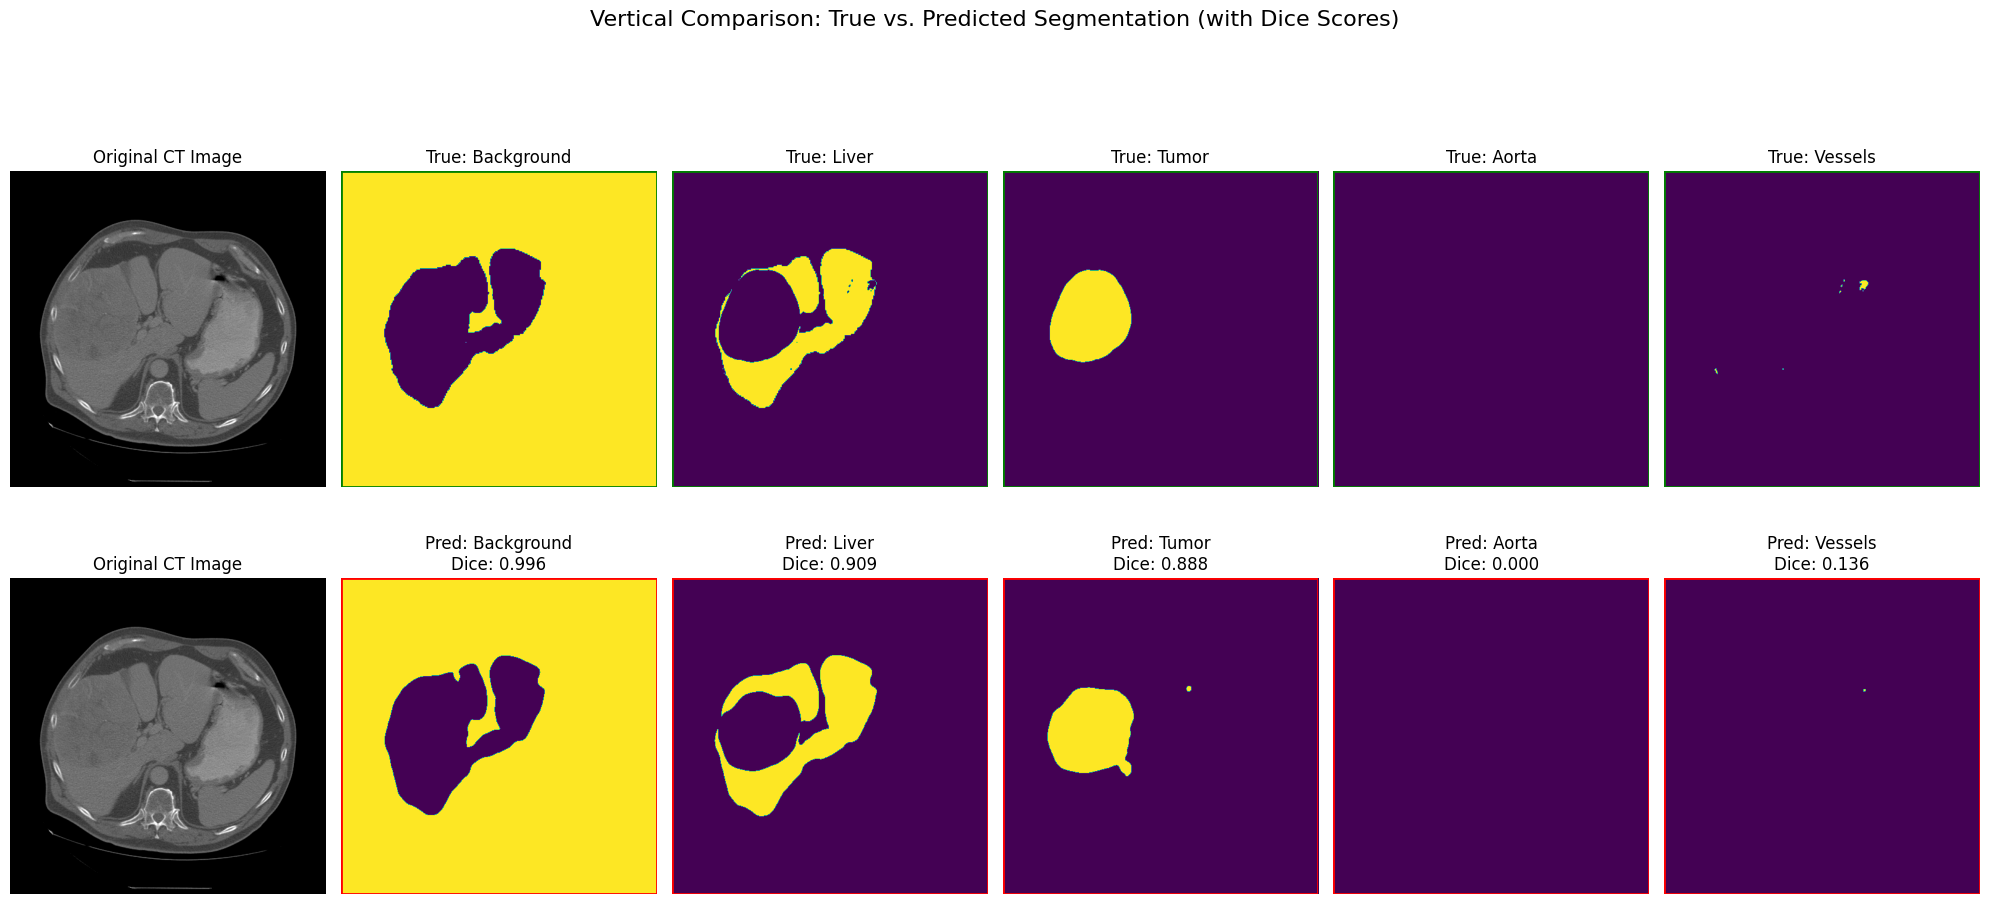

In [16]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class Visualizer:
    """
    A class for visualizing segmentation results with vertical comparison.
    
    It displays the original CT image (normalized from -1024 to 1024) along with the true masks
    and predicted masks, arranged in two rows (true masks in the top row, predicted masks in the bottom row),
    with the original image shown in the first column of both rows.
    """
    def __init__(self, model, device=None, cmap_image='gray', cmap_mask='viridis'):
        """
        Args:
            model (torch.nn.Module): Trained segmentation model.
            device (torch.device, optional): Device to perform computations.
                                              Defaults to GPU if available.
            cmap_image (str): Colormap for the original image.
            cmap_mask (str): Colormap for displaying masks.
        """
        self.model = model
        self.device = device if device is not None else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.cmap_image = cmap_image
        self.cmap_mask = cmap_mask

    def visualize_vertical_comparison(self, image_path, base_mask_path, class_labels, threshold=0.5, figsize=(20,10), save_path=None):
        """
        Visualize a vertical comparison of the original CT image, true masks, and predicted masks.
        
        The layout is arranged as follows:
            - The first column in both rows shows the original CT image.
            - The top row (columns 2 to N+1) shows the true masks.
            - The bottom row (columns 2 to N+1) shows the predicted masks.
        
        Args:
            image_path (str): Path to the .npy file containing the CT image.
            base_mask_path (str): Base path for the masks; use 'X' as a placeholder
                                  for class names (e.g., '/path/to/masks/X_image.npy').
            class_labels (list): List of class labels (first label must be 'Background').
            threshold (float, optional): Threshold for converting prediction probabilities to binary.
                                         Defaults to 0.5.
            figsize (tuple, optional): Figure size.
            save_path (str, optional): If provided, the figure will be saved to this path.
        """
        # Load and preprocess the CT image.
        image = np.load(image_path)
        # from matplotlib import pyplot as plt
        # plt.imshow(image, cmap=plt.get_cmap('gray'))
        # plt.show()
        # Normalize CT image from [-1024, 1024] to [0, 1]
        image = (image + 1024) / 2048.0
        # print(image.min())
        # print(image.max())
        # imagex = ((image >= 0.85) & (image <= 1.35))
        # imagex = ((image >= 0.4) & (image <= 0.6))
        image = np.clip(image, a_min = 0.85, a_max = 1.3)

        # Use np.where to assign 1 if the condition is met, else 0
        # image = np.where(imagex, image, 0)
        # print(image[250])
        # from matplotlib import pyplot as plt
        # plt.imshow(image, cmap=plt.get_cmap('gray'))
        # plt.show()
        
        image_expanded = np.expand_dims(image, axis=0)  # shape: (1, H, W)

        # Load true masks for each class (except background).
        true_masks = []
        for class_name in class_labels[1:]:
            class_path = base_mask_path.replace('X', class_name.lower())
            try:
                mask = np.load(class_path)
            except FileNotFoundError:
                mask = np.zeros_like(image.squeeze())
            true_masks.append(mask)
        true_masks = np.stack(true_masks, axis=0)  # shape: (num_classes-1, H, W)
        # Compute background mask: background is 1 where none of the other masks are present.
        background = 1 - np.any(true_masks, axis=0)
        # Concatenate background with other masks.
        true_mask = np.concatenate([background[np.newaxis, ...], true_masks], axis=0)  # shape: (num_classes, H, W)

        # Model prediction.
        # Create a tensor from the image; note that image_expanded is (1, H, W), so we add a channel dim.
        image_tensor = torch.tensor(image_expanded, dtype=torch.float32).unsqueeze(0).to(self.device)  # (1, 1, H, W)
        with torch.no_grad():
            output = self.model(image_tensor)
            # If model returns a tuple (e.g., (main_out, aux_out)), use the main output.
            if isinstance(output, (tuple, list)):
                output = output[0]
            # Apply softmax to get probabilities.
            prediction = torch.softmax(output, dim=1).squeeze(0).cpu().numpy()  # (num_classes, H, W)

        # Create a figure: 2 rows and (num_classes+1) columns.
        num_classes = len(class_labels)
        fig, axs = plt.subplots(2, num_classes + 1, figsize=figsize)
        fig.suptitle("Vertical Comparison: True vs. Predicted Segmentation", fontsize=16)

        def add_group_border(ax, color='blue', linewidth=2):
            """Add a border around the entire axes."""
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
            width = xlim[1] - xlim[0]
            height = ylim[0] - ylim[1]
            rect = patches.Rectangle((xlim[0], ylim[1]), width, height,
                                     linewidth=linewidth, edgecolor=color, facecolor='none', transform=ax.transData)
            ax.add_patch(rect)

        # Plot the original CT image in the first column of both rows.
        # Multiply by 255 for display if desired.
        for row in range(2):
            axs[row, 0].imshow(image.squeeze()*255, cmap=self.cmap_image)
            axs[row, 0].axis('off')
            axs[row, 0].set_title("Original CT Image", fontsize=12)

        # Plot masks for each class.
        for idx, label in enumerate(class_labels):
            # True mask (top row)
            ax_true = axs[0, idx + 1]
            ax_true.imshow(true_mask[idx]*255, cmap=self.cmap_mask)
            ax_true.set_title(f"True: {label}", fontsize=12)
            ax_true.axis('off')
            add_group_border(ax_true, color='green', linewidth=2)

            # Predicted mask (bottom row)
            ax_pred = axs[1, idx + 1]
            pred_mask = (prediction[idx] >= threshold).astype(float) * 255
            ax_pred.imshow(pred_mask, cmap=self.cmap_mask)
            ax_pred.set_title(f"Pred: {label}", fontsize=12)
            ax_pred.axis('off')
            add_group_border(ax_pred, color='red', linewidth=2)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        if save_path:
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()


import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class SegmentationVisualizer:
    """
    A class for visualizing segmentation results with vertical comparison.
    
    It displays the original CT image (normalized from -1024 to 1024) along with the true masks
    and predicted masks, arranged in two rows (true masks in the top row, predicted masks in the bottom row),
    with the original image shown in the first column of both rows. It also computes and displays the Dice score
    for each class.
    """
    def __init__(self, model, device=None, cmap_image='gray', cmap_mask='viridis'):
        """
        Args:
            model (torch.nn.Module): Trained segmentation model.
            device (torch.device, optional): Device to perform computations.
                                              Defaults to GPU if available.
            cmap_image (str): Colormap for the original image.
            cmap_mask (str): Colormap for displaying masks.
        """
        self.model = model
        self.device = device if device is not None else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.cmap_image = cmap_image
        self.cmap_mask = cmap_mask

    def visualize_vertical_comparison(self, image_path, base_mask_path, class_labels, threshold=0.5, figsize=(20,10), save_path=None):
        """
        Visualize a vertical comparison of the original CT image, true masks, and predicted masks,
        along with the Dice score for each class.
        
        The layout is arranged as follows:
            - The first column in both rows shows the original CT image.
            - The top row (columns 2 to N+1) shows the true masks.
            - The bottom row (columns 2 to N+1) shows the predicted masks, with Dice scores in the title.
        
        Args:
            image_path (str): Path to the .npy file containing the CT image.
            base_mask_path (str): Base path for the masks; use 'X' as a placeholder
                                  for class names (e.g., '/path/to/masks/X_image.npy').
            class_labels (list): List of class labels (first label must be 'Background').
            threshold (float, optional): Threshold for converting prediction probabilities to binary.
                                         Defaults to 0.5.
            figsize (tuple, optional): Figure size.
            save_path (str, optional): If provided, the figure will be saved to this path.
        """
        # Load and preprocess the CT image.
        image = np.load(image_path)
        # Normalize CT image from [-1024, 1024] to [0, 1]
        image = (image + 1024) / 2048.0
        # Clip the image as desired (here the clipping range is adjustable)
        image = np.clip(image, a_min=0.85, a_max=1.3)
        image_expanded = np.expand_dims(image, axis=0)  # shape: (1, H, W)

        # Load true masks for each class (except background).
        true_masks = []
        for class_name in class_labels[1:]:
            class_path = base_mask_path.replace('X', class_name.lower())
            try:
                mask = np.load(class_path)
            except FileNotFoundError:
                mask = np.zeros_like(image.squeeze())
            true_masks.append(mask)
        true_masks = np.stack(true_masks, axis=0)  # shape: (num_classes-1, H, W)
        # Compute background mask: background is 1 where none of the other masks are present.
        background = 1 - np.any(true_masks, axis=0)
        # Concatenate background with other masks.
        true_mask = np.concatenate([background[np.newaxis, ...], true_masks], axis=0)  # shape: (num_classes, H, W)
        # Ensure true_mask is binary.
        true_mask = (true_mask > 0.5).astype(np.float32)

        # Model prediction.
        image_tensor = torch.tensor(image_expanded, dtype=torch.float32).unsqueeze(0).to(self.device)  # (1, 1, H, W)
        with torch.no_grad():
            output = self.model(image_tensor)
            # If model returns a tuple (e.g., (main_out, aux_out)), use the main output.
            if isinstance(output, (tuple, list)):
                output = output[0]
            # Apply softmax to get probabilities.
            prediction = torch.softmax(output, dim=1).squeeze(0).cpu().numpy()  # shape: (num_classes, H, W)
        
        num_classes = len(class_labels)
        # Compute Dice scores for each class.
        dice_scores = []
        for idx in range(num_classes):
            # For prediction, threshold the probabilities.
            pred_binary = (prediction[idx] >= threshold)
            # For true mask, use boolean version.
            true_binary = (true_mask[idx] > 0.5)
            intersection = np.sum(pred_binary & true_binary)
            union = np.sum(pred_binary) + np.sum(true_binary)
            dice = (2.0 * intersection) / (union + 1e-6)
            dice_scores.append(dice)

        # Create a figure: 2 rows and (num_classes+1) columns.
        fig, axs = plt.subplots(2, num_classes + 1, figsize=figsize)
        fig.suptitle("Vertical Comparison: True vs. Predicted Segmentation (with Dice Scores)", fontsize=16)

        def add_group_border(ax, color='blue', linewidth=2):
            """Add a border around the entire axes."""
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
            width = xlim[1] - xlim[0]
            height = ylim[0] - ylim[1]
            rect = patches.Rectangle((xlim[0], ylim[1]), width, height,
                                     linewidth=linewidth, edgecolor=color, facecolor='none', transform=ax.transData)
            ax.add_patch(rect)

        # Plot the original CT image in the first column of both rows.
        for row in range(2):
            axs[row, 0].imshow(image.squeeze()*255, cmap=self.cmap_image)
            axs[row, 0].axis('off')
            axs[row, 0].set_title("Original CT Image", fontsize=12)

        # Plot masks for each class.
        for idx, label in enumerate(class_labels):
            # True mask (top row)
            ax_true = axs[0, idx + 1]
            ax_true.imshow(true_mask[idx]*255, cmap=self.cmap_mask)
            ax_true.set_title(f"True: {label}", fontsize=12)
            ax_true.axis('off')
            add_group_border(ax_true, color='green', linewidth=2)

            # Predicted mask (bottom row)
            ax_pred = axs[1, idx + 1]
            pred_mask = (prediction[idx] >= threshold).astype(np.float32)
            ax_pred.imshow(pred_mask*255, cmap=self.cmap_mask)
            # Append the Dice score to the title.
            ax_pred.set_title(f"Pred: {label}\nDice: {dice_scores[idx]:.3f}", fontsize=12)
            ax_pred.axis('off')
            add_group_border(ax_pred, color='red', linewidth=2)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        if save_path:
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()



# Example usage:
# Assuming `unet_model` is your trained segmentation model.
visualizer = SegmentationVisualizer(unet_model)
visualizer.visualize_vertical_comparison(
    image_path='/kaggle/input/nowindow-raw/OUTPUT/ct_images/HCC_058/HCC_058_44.npy',
    base_mask_path='/kaggle/input/nowindow-raw/OUTPUT/X/HCC_058/HCC_058_44.npy',
    class_labels=['Background', 'Liver', 'Tumor', 'Aorta', 'Vessels'],
    threshold=0.25,
    figsize=(20, 10),
    save_path=None  # Or provide a file path to save the figure
)


In [17]:
optimzer = optim.Adam(unet_model.parameters(), lr = 1e-5)
num_epochs = 15
for epoch in range(num_epochs):
    unet_model.train()
    running_loss = 0.0
    for i, (ct_images, masks) in enumerate(tqdm(train_dataloader)):
        ct_images = ct_images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        main_out, aux_out = unet_model(ct_images)

        main_loss = criterion(main_out, masks)
        aux_loss = criterion(aux_out, masks)

        loss = main_loss # + 0.4 * aux_loss
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_dataloader)}')
    
    # Validation phase
    unet_model.eval()
    val_loss = 0.0
    # dice_scores = []
    with torch.no_grad():
        for val_images, val_masks in val_dataloader:
            val_images = val_images.to(device)
            val_masks = val_masks.to(device)
            main_out, _ = unet_model(val_images)  # Use the main output for evaluation
            loss = criterion(main_out, val_masks)
            val_loss += loss.item()
            
            # # Assuming dice_function computes Dice for a batch
            # dice = dice_function(main_out, val_masks)
            # dice_scores.append(dice)
    
    avg_val_loss = val_loss / len(val_dataloader)
    # avg_dice = np.mean(dice_scores)
    print(f"Epoch {epoch + 1}: Val Loss = {avg_val_loss:.4f}")
    
    # # Optional: Save model checkpoint if validation performance improved
    # if avg_dice > best_val_dice:
    #     best_val_dice = avg_dice
    #     torch.save(model.state_dict(), "best_model.pth")

    
torch.save(unet_model.state_dict(), 'unet_multiclass_2.pth')

100%|██████████| 239/239 [04:57<00:00,  1.25s/it]


Epoch 1/15, Loss: 0.032789112805197924
Epoch 1: Val Loss = 0.0413


100%|██████████| 239/239 [04:57<00:00,  1.25s/it]


Epoch 2/15, Loss: 0.028129806258875456
Epoch 2: Val Loss = 0.0462


100%|██████████| 239/239 [04:58<00:00,  1.25s/it]


...

Epoch 13/15, Loss: 0.015744740480486942
Epoch 13: Val Loss = 0.0378


100%|██████████| 239/239 [04:58<00:00,  1.25s/it]


Epoch 14/15, Loss: 0.01711983170173283
Epoch 14: Val Loss = 0.0346


100%|██████████| 239/239 [04:58<00:00,  1.25s/it]


Epoch 15/15, Loss: 0.015060432913818369
Epoch 15: Val Loss = 0.0353


In [18]:
%%time
evaluator = SegmentationEvaluator(unet_model, num_classes=5, eval_batch_size=4)

# Evaluate on the training dataset
train_dice_scores = evaluator.evaluate_dice(train_dataset)
print("Train Dice Scores per Class:", train_dice_scores)

# Evaluate on the validation dataset
val_dice_scores = evaluator.evaluate_dice(val_dataset)
print("Val Dice Scores per Class:", val_dice_scores)

# Evaluate on the test dataset
test_dice_scores = evaluator.evaluate_dice(test_dataset)
print("Test Dice Scores per Class:", test_dice_scores)

Train Dice Scores per Class: {0: 0.9979295440388418, 1: 0.9401144013800131, 2: 0.879812027491231, 3: 0.8637232665384753, 4: 0.42880453156532544}
Val Dice Scores per Class: {0: 0.9958284757231588, 1: 0.8962937805698268, 2: 0.7467985879149168, 3: 0.6456061186217994, 4: 0.4049897736651961}
Test Dice Scores per Class: {0: 0.9828977053260441, 1: 0.7515900267534433, 2: 0.24963187509786713, 3: 0.2633347623976089, 4: 0.21693663127619106}
CPU times: user 3min 51s, sys: 5.29 s, total: 3min 56s
Wall time: 3min 18s


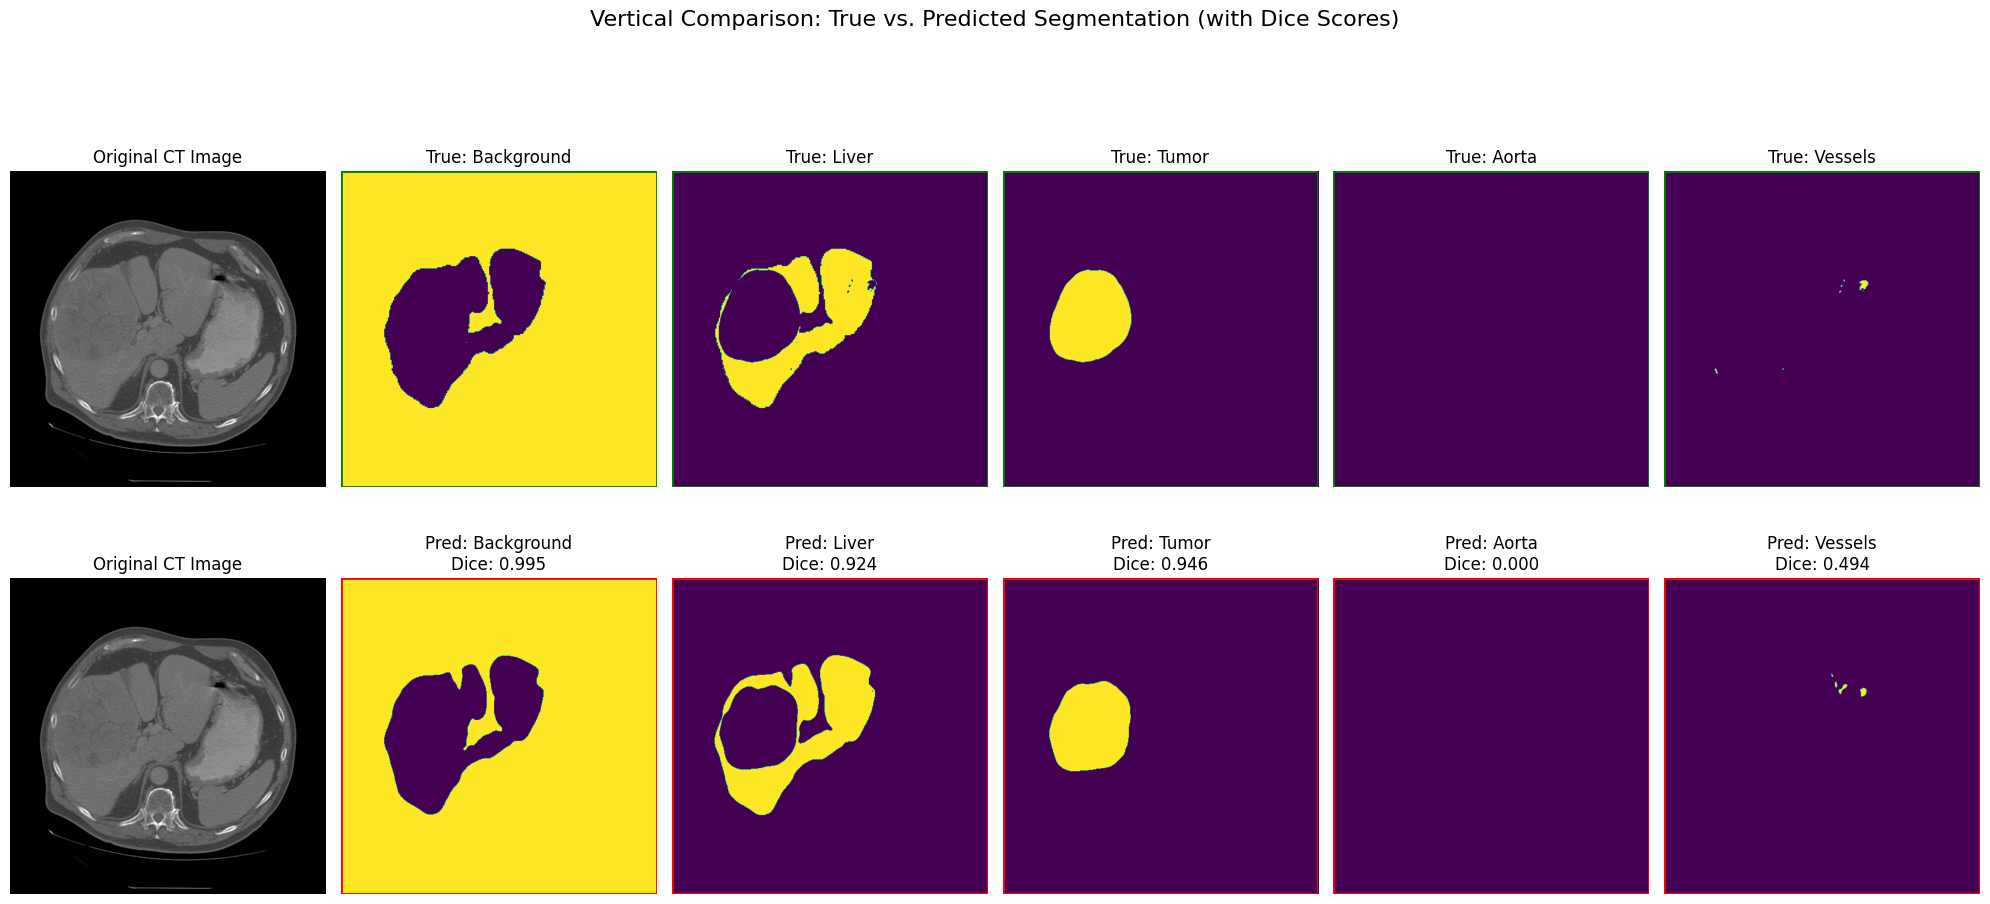

In [19]:
visualizer = SegmentationVisualizer(unet_model)
visualizer.visualize_vertical_comparison(
    image_path='/kaggle/input/nowindow-raw/OUTPUT/ct_images/HCC_058/HCC_058_44.npy',
    base_mask_path='/kaggle/input/nowindow-raw/OUTPUT/X/HCC_058/HCC_058_44.npy',
    class_labels=['Background', 'Liver', 'Tumor', 'Aorta', 'Vessels'],
    threshold=0.25,
    figsize=(20, 10),
    save_path=None  # Or provide a file path to save the figure
)


In [20]:
optimzer = optim.Adam(unet_model.parameters(), lr = 1e-6)
num_epochs = 5
for epoch in range(num_epochs):
    unet_model.train()
    running_loss = 0.0
    for i, (ct_images, masks) in enumerate(tqdm(train_dataloader)):
        ct_images = ct_images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        main_out, aux_out = unet_model(ct_images)

        main_loss = criterion(main_out, masks)
        aux_loss = criterion(aux_out, masks)

        loss = main_loss + 0.4 * aux_loss
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_dataloader)}')
    
    # Validation phase
    unet_model.eval()
    val_loss = 0.0
    # dice_scores = []
    with torch.no_grad():
        for val_images, val_masks in val_dataloader:
            val_images = val_images.to(device)
            val_masks = val_masks.to(device)
            main_out, _ = unet_model(val_images)  # Use the main output for evaluation
            loss = criterion(main_out, val_masks)
            val_loss += loss.item()
            
            # # Assuming dice_function computes Dice for a batch
            # dice = dice_function(main_out, val_masks)
            # dice_scores.append(dice)
    
    avg_val_loss = val_loss / len(val_dataloader)
    # avg_dice = np.mean(dice_scores)
    print(f"Epoch {epoch + 1}: Val Loss = {avg_val_loss:.4f}")
    
    # # Optional: Save model checkpoint if validation performance improved
    # if avg_dice > best_val_dice:
    #     best_val_dice = avg_dice
    #     torch.save(model.state_dict(), "best_model.pth")

    
torch.save(unet_model.state_dict(), 'unet_multiclass_3.pth')

100%|██████████| 239/239 [04:59<00:00,  1.25s/it]


Epoch 1/5, Loss: 0.020380650857408925
Epoch 1: Val Loss = 0.0374


100%|██████████| 239/239 [04:59<00:00,  1.25s/it]


Epoch 2/5, Loss: 0.01984315787960296
Epoch 2: Val Loss = 0.0409


100%|██████████| 239/239 [05:22<00:00,  1.35s/it]


Epoch 3/5, Loss: 0.02034381266963906
Epoch 3: Val Loss = 0.0398


100%|██████████| 239/239 [05:05<00:00,  1.28s/it]


Epoch 4/5, Loss: 0.018916431674149244
Epoch 4: Val Loss = 0.0341


100%|██████████| 239/239 [05:00<00:00,  1.26s/it]


Epoch 5/5, Loss: 0.018514947069489307
Epoch 5: Val Loss = 0.0345


In [21]:
%%time
evaluator = SegmentationEvaluator(unet_model, num_classes=5, eval_batch_size=4)

# Evaluate on the training dataset
train_dice_scores = evaluator.evaluate_dice(train_dataset)
print("Train Dice Scores per Class:", train_dice_scores)

# Evaluate on the validation dataset
val_dice_scores = evaluator.evaluate_dice(val_dataset)
print("Val Dice Scores per Class:", val_dice_scores)

# Evaluate on the test dataset
test_dice_scores = evaluator.evaluate_dice(test_dataset)
print("Test Dice Scores per Class:", test_dice_scores)

Train Dice Scores per Class: {0: 0.9982236715783492, 1: 0.9466526377010321, 2: 0.8921953712327005, 3: 0.9165217238478363, 4: 0.4603599164075126}
Val Dice Scores per Class: {0: 0.9961312584284335, 1: 0.9024611589167421, 2: 0.7536608526821841, 3: 0.7230668940557325, 4: 0.42665162607716645}
Test Dice Scores per Class: {0: 0.9841836269598532, 1: 0.7583949798411272, 2: 0.25937334202027873, 3: 0.2823103122948283, 4: 0.23793793099325464}
CPU times: user 3min 51s, sys: 5.35 s, total: 3min 57s
Wall time: 3min 19s


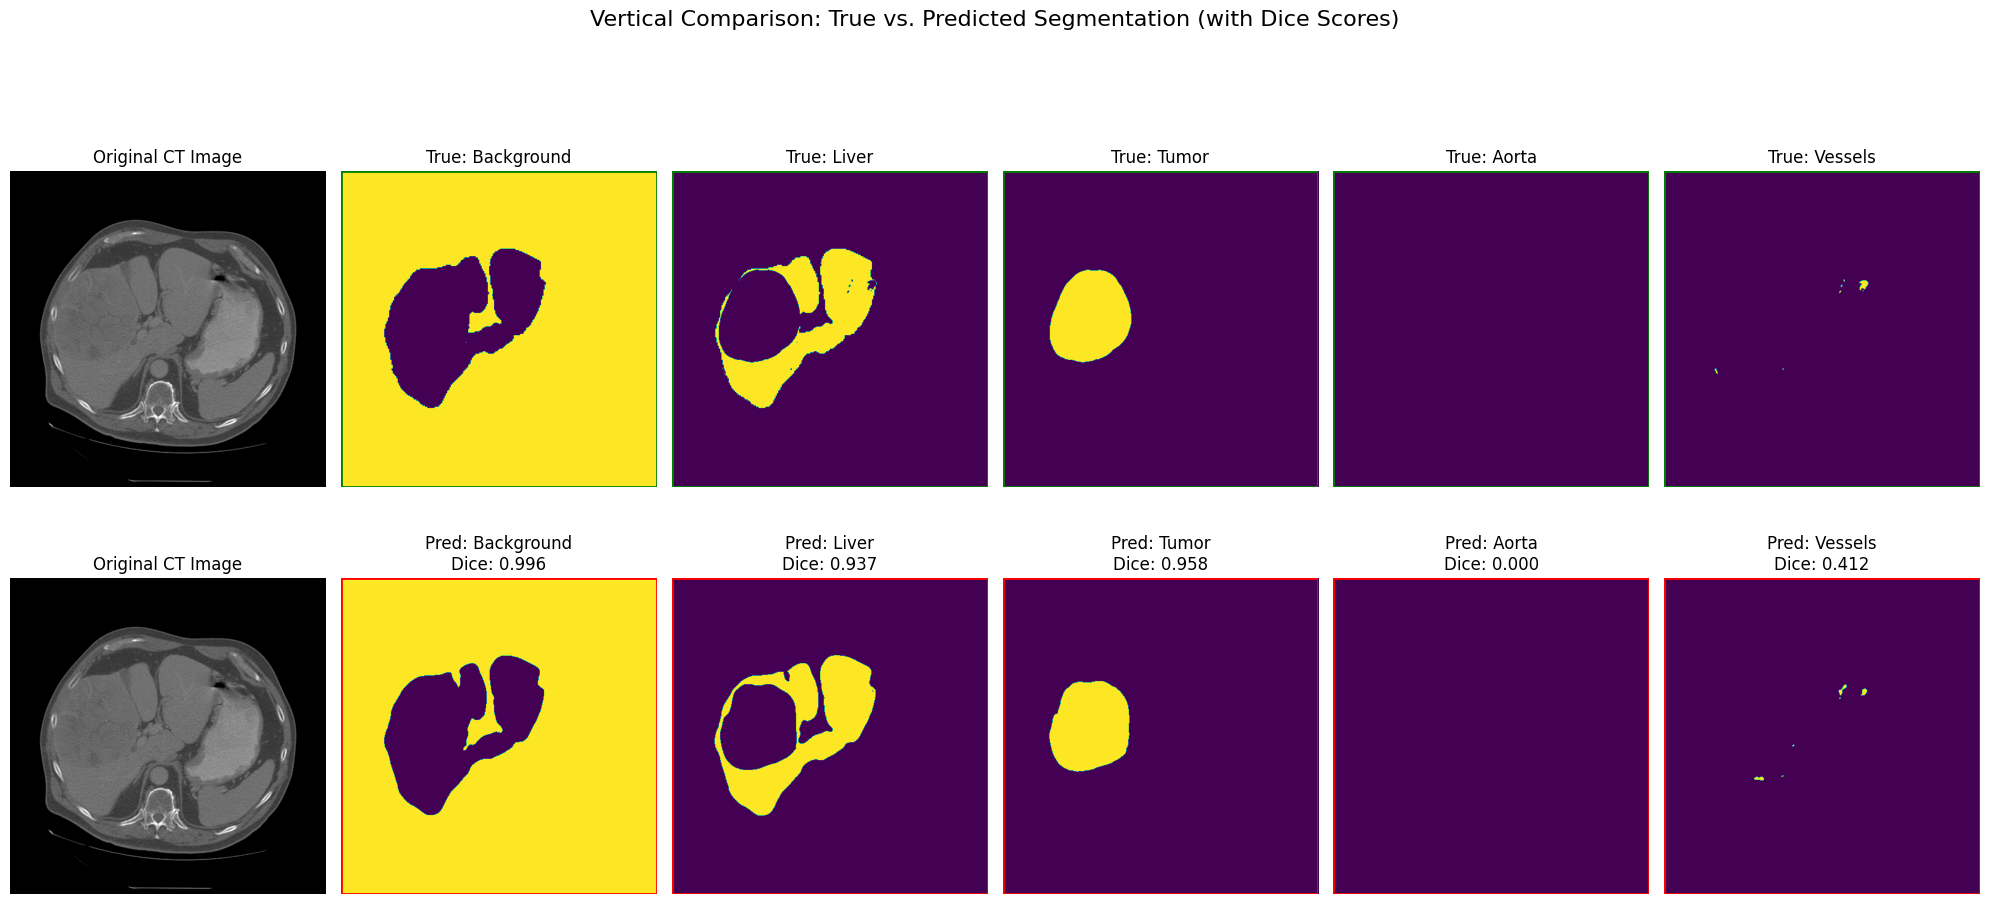

In [22]:
visualizer = SegmentationVisualizer(unet_model)
visualizer.visualize_vertical_comparison(
    image_path='/kaggle/input/nowindow-raw/OUTPUT/ct_images/HCC_058/HCC_058_44.npy',
    base_mask_path='/kaggle/input/nowindow-raw/OUTPUT/X/HCC_058/HCC_058_44.npy',
    class_labels=['Background', 'Liver', 'Tumor', 'Aorta', 'Vessels'],
    threshold=0.25,
    figsize=(20, 10),
    save_path=None  # Or provide a file path to save the figure
)


In [23]:
optimzer = optim.Adam(unet_model.parameters(), lr = 1e-8)
num_epochs = 1
for epoch in range(num_epochs):
    unet_model.train()
    running_loss = 0.0
    for i, (ct_images, masks) in enumerate(tqdm(train_dataloader)):
        ct_images = ct_images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        main_out, aux_out = unet_model(ct_images)

        main_loss = criterion(main_out, masks)
        aux_loss = criterion(aux_out, masks)

        loss = main_loss + 0.4 * aux_loss
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_dataloader)}')
    
    # Validation phase
    unet_model.eval()
    val_loss = 0.0
    # dice_scores = []
    with torch.no_grad():
        for val_images, val_masks in val_dataloader:
            val_images = val_images.to(device)
            val_masks = val_masks.to(device)
            main_out, _ = unet_model(val_images)  # Use the main output for evaluation
            loss = criterion(main_out, val_masks)
            val_loss += loss.item()
            
            # # Assuming dice_function computes Dice for a batch
            # dice = dice_function(main_out, val_masks)
            # dice_scores.append(dice)
    
    avg_val_loss = val_loss / len(val_dataloader)
    # avg_dice = np.mean(dice_scores)
    print(f"Epoch {epoch + 1}: Val Loss = {avg_val_loss:.4f}")
    
    # # Optional: Save model checkpoint if validation performance improved
    # if avg_dice > best_val_dice:
    #     best_val_dice = avg_dice
    #     torch.save(model.state_dict(), "best_model.pth")

    
torch.save(unet_model.state_dict(), 'unet_multiclass_fin.pth')

100%|██████████| 239/239 [04:59<00:00,  1.25s/it]


Epoch 1/1, Loss: 0.01788820980592128
Epoch 1: Val Loss = 0.0411


In [24]:
%%time
evaluator = SegmentationEvaluator(unet_model, num_classes=5, eval_batch_size=4)

# Evaluate on the training dataset
train_dice_scores = evaluator.evaluate_dice(train_dataset)
print("Train Dice Scores per Class:", train_dice_scores)

# Evaluate on the validation dataset
val_dice_scores = evaluator.evaluate_dice(val_dataset)
print("Val Dice Scores per Class:", val_dice_scores)

# Evaluate on the test dataset
test_dice_scores = evaluator.evaluate_dice(test_dataset)
print("Test Dice Scores per Class:", test_dice_scores)

Train Dice Scores per Class: {0: 0.9969659345000899, 1: 0.9273273577735848, 2: 0.8438457994696402, 3: 0.8689124149490043, 4: 0.3813573892893021}
Val Dice Scores per Class: {0: 0.9949024490043942, 1: 0.8867188716153838, 2: 0.700964847444208, 3: 0.7037016172680939, 4: 0.35396415476543713}
Test Dice Scores per Class: {0: 0.9827566680125539, 1: 0.7310632361979937, 2: 0.23443565239921915, 3: 0.311978042966227, 4: 0.18067613492280166}
CPU times: user 3min 48s, sys: 4.97 s, total: 3min 53s
Wall time: 3min 14s


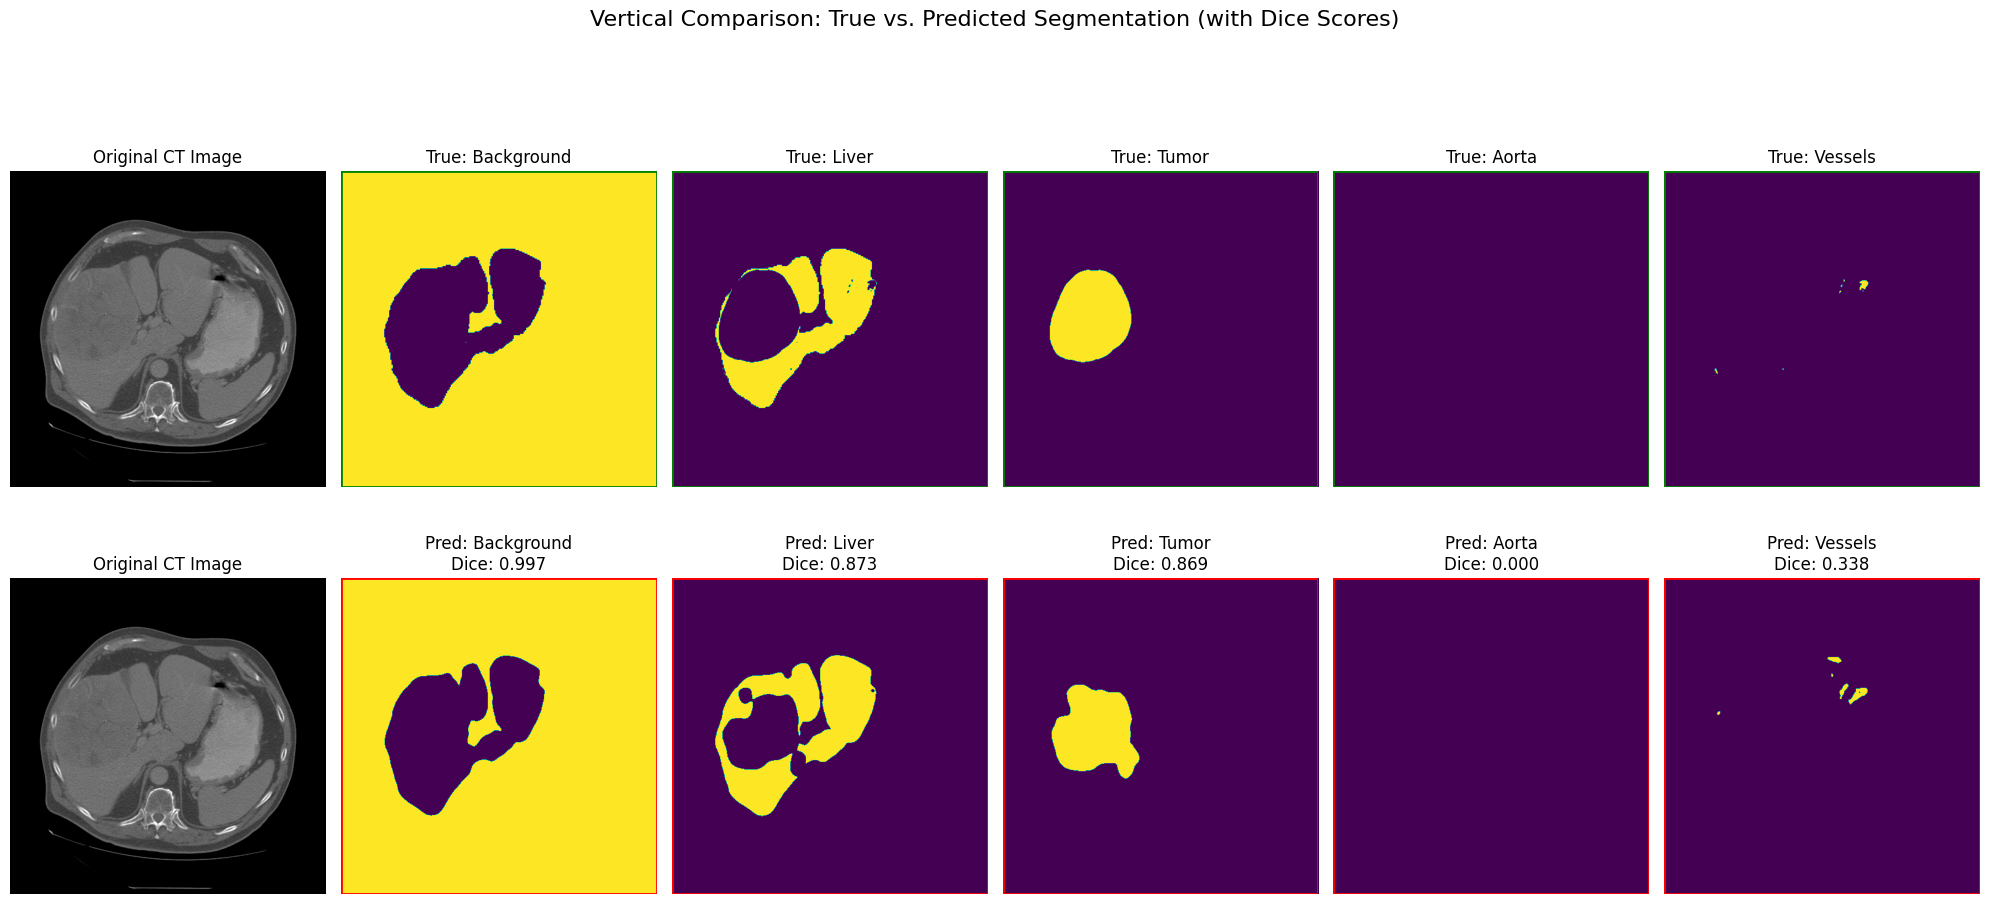

In [25]:
visualizer = SegmentationVisualizer(unet_model)
visualizer.visualize_vertical_comparison(
    image_path='/kaggle/input/nowindow-raw/OUTPUT/ct_images/HCC_058/HCC_058_44.npy',
    base_mask_path='/kaggle/input/nowindow-raw/OUTPUT/X/HCC_058/HCC_058_44.npy',
    class_labels=['Background', 'Liver', 'Tumor', 'Aorta', 'Vessels'],
    threshold=0.25,
    figsize=(20, 10),
    save_path=None  # Or provide a file path to save the figure
)
